<h1 style="color: #122A5E; text-align: center; font-size: 50px; font-weight: 400; font-family: Georgia, 'Times New Roman', serif;">
    Project 1: Greek Hedging
</h1>

<div style="text-align: center;">
    <img src="logo.png" width="500">
</div>

<h1 style="color: #122A5E; text-align: center; font-size: 40px; font-weight: 400; font-family: Georgia, 'Times New Roman', serif;">
    Quantitative Finance
</h1>

<h2 style="color: #122A5E; text-align: center; font-size: 20px; font-weight: 300; font-family: Georgia, 'Times New Roman', serif;">
    Ivanna Herrera Ibarra<br>
    Ana Sofía Hinojosa Bale<br>
    Julia Hernández Cárdenas
</h2>
<div style="text-align: center;">
</div>


<h1 style="color: #122A5E; text-align: left; font-size: 40px; font-weight: 400; font-family: Georgia, 'Times New Roman', serif;">
    Library Imports and Class Definition
</h1>

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MultipleLocator
import scipy.stats as si
from scipy.optimize import minimize
from matplotlib.colors import LinearSegmentedColormap

In [2]:
class Calculations:
    def __init__(self, S, K, T, r, sigma):
        self.S = S
        self.K = K
        self.T = T
        self.r = r
        self.sigma = sigma

    def d1(self):
        return (np.log(self.S / self.K) + (self.r + 0.5 * self.sigma**2) * self.T) / (self.sigma * np.sqrt(self.T))
    
    def d2(self):
        return self.d1() - self.sigma * np.sqrt(self.T)

    def delta(self):
        return norm.cdf(self.d1())
    
    def gamma(self):
        return norm.pdf(self.d1()) / (self.S * self.sigma * np.sqrt(self.T))
    
    def aux_imp_vol(self, S, K, sigma, r, T, t):
        d1 = (np.log(S/K)+(r + 0.5 * sigma * sigma) * (T - t))/(sigma * np.sqrt(T - t))
        d2 = d1 - sigma * np.sqrt(T - t)
        Nd1= si.norm.cdf(d1, 0.0, 1.0)
        Nd2= si.norm.cdf(d2, 0.0, 1.0)
        ECall= S * Nd1 - K * np.exp(-r * (T - t))* Nd2
        return ECall
    
    def get_implied_vol(self, S, K, T, r, CallMkt, t=0, sigma0=0.3):
        apply_constraint = lambda sigma: self.aux_imp_vol(S, K, sigma[0], r, T, t) - CallMkt
        
        bounds = [[None, None]]
        constraints = ({'type': 'eq', 'fun': apply_constraint})
        
        result = minimize(
            self.aux_imp_vol,
            sigma0,
            bounds=bounds,
            constraints=constraints,
            method='SLSQP',
            args=(S, K, r, T, t)
        )
        return result.x[0]

<h1 style="color: #122A5E; text-align: left; font-size: 40px; font-weight: 400; font-family: Georgia, 'Times New Roman', serif;">
    Data and Initial Calculations
</h1>

In [3]:
df = pd.read_excel('Datos AAPL proyecto cuanti.xlsx', sheet_name='Hoja2')
df_filtered = df.head(10)
df_filtered = df_filtered.drop(columns=['Contract Name', 'Last Trade Date (EST)', 'Bid', 'Ask', 'Change', '% Change', 'Volume', 'Open Interest', 'Implied Volatility'])
df_filtered['Expiration Date'] = pd.Timestamp('2026-04-09')
df_filtered

,Strike,Last Price,Type,Date,Price,Expiration Date
0,185,65.07,Calls,2026-01-22,248.35,2026-04-09
1,195,56.00,Calls,2026-01-22,248.35,2026-04-09
2,215,40.90,Calls,2026-01-22,248.35,2026-04-09
3,225,33.85,Calls,2026-01-22,248.35,2026-04-09
4,240,21.40,Calls,2026-01-22,248.35,2026-04-09
5,250,15.45,Calls,2026-01-22,248.35,2026-04-09
6,265,8.75,Calls,2026-01-22,248.35,2026-04-09
7,275,5.78,Calls,2026-01-22,248.35,2026-04-09
8,295,2.52,Calls,2026-01-22,248.35,2026-04-09
9,305,1.53,Calls,2026-01-22,248.35,2026-04-09


In [4]:
strikes = df_filtered['Strike'].tolist()
last_prices = df_filtered['Last Price'].tolist()
prices_df = pd.read_excel('Datos AAPL proyecto cuanti.xlsx', sheet_name='Hoja3')

In [5]:
prices_df['Remaining_Time'] = (pd.Timestamp('2026-04-09') - prices_df['Date']).dt.days
prices_df['Remaining_Time'] = prices_df['Remaining_Time'].replace(0, 0.0001)
prices_df['T_Years'] = prices_df['Remaining_Time'] / 365
sigma = prices_df['Price'].pct_change().std() * (252 ** 0.5)
prices_df['Sigma_Fixed'] = sigma
prices_df['R_Cont'] = 0.0426
last_price = prices_df['Price'].iloc[-1]
prices_df

,Date,Price,Remaining_Time,T_Years,Sigma_Fixed,R_Cont
0,2026-01-22,248.35,77.0000,2.109589e-01,0.384354,0.0426
1,2026-01-27,258.27,72.0000,1.972603e-01,0.384354,0.0426
2,2026-01-29,258.28,70.0000,1.917808e-01,0.384354,0.0426
3,2026-02-03,269.48,65.0000,1.780822e-01,0.384354,0.0426
4,2026-02-05,275.91,63.0000,1.726027e-01,0.384354,0.0426
5,2026-02-10,273.68,58.0000,1.589041e-01,0.384354,0.0426
6,2026-02-12,261.73,56.0000,1.534247e-01,0.384354,0.0426
7,2026-02-17,263.88,51.0000,1.397260e-01,0.384354,0.0426
8,2026-02-19,260.58,49.0000,1.342466e-01,0.384354,0.0426
9,2026-02-24,272.14,44.0000,1.205479e-01,0.384354,0.0426


<h1 style="color: steelblue; text-align: left; font-size: 35px; font-weight: 400; font-family: Georgia, 'Times New Roman', serif;">
    Implied Volatility Calculation
</h1>

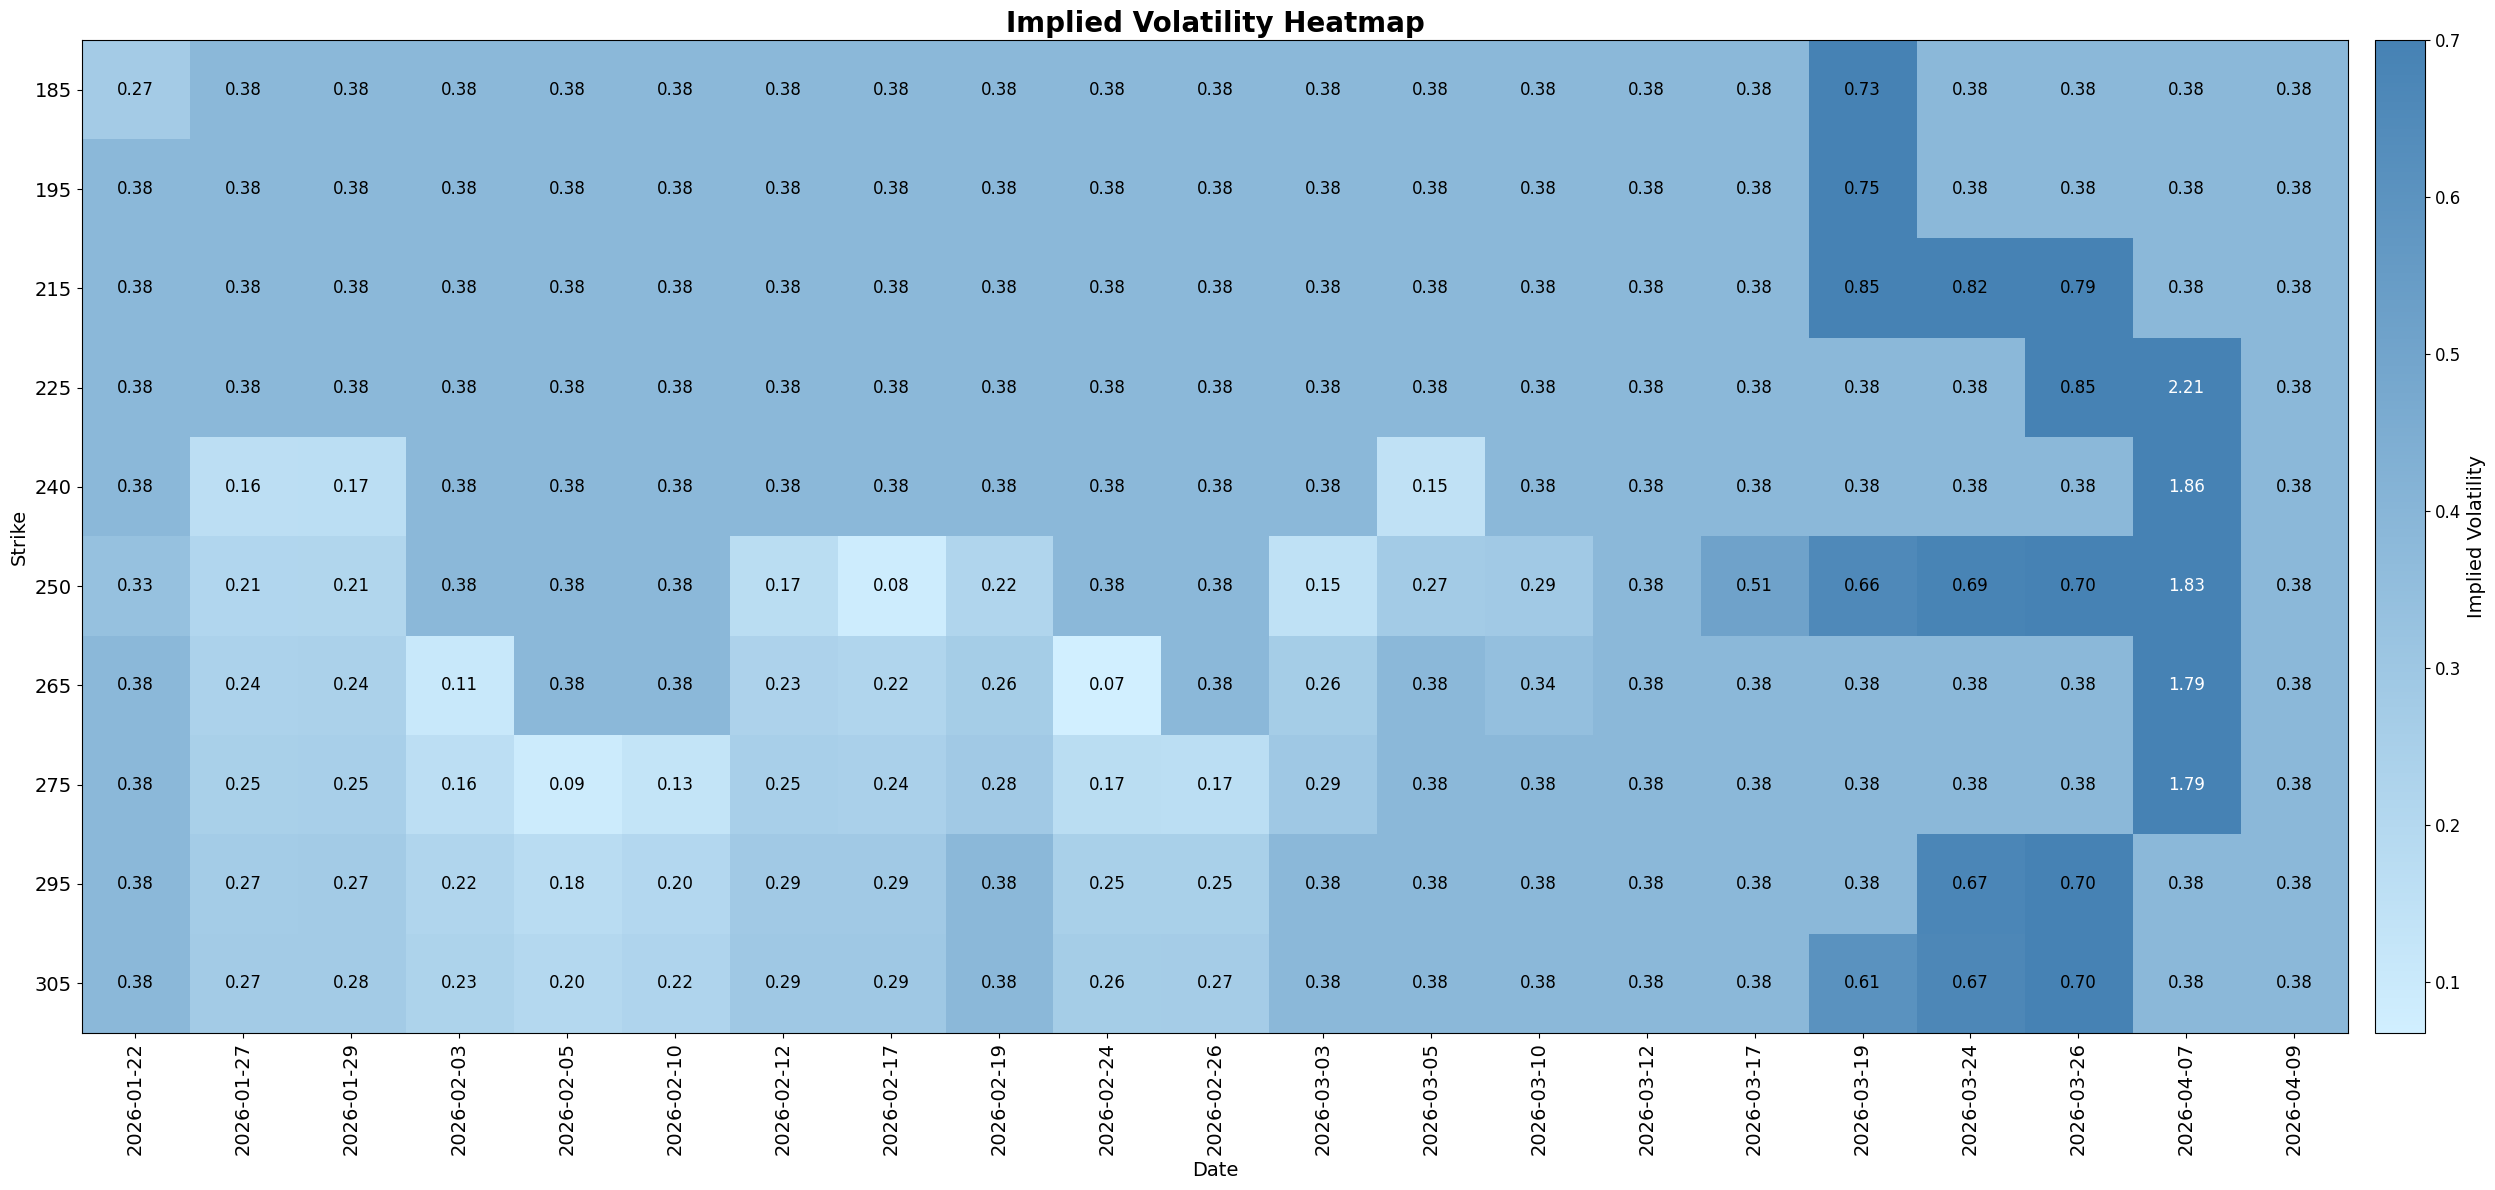

In [37]:
results = {}
dates = prices_df['Date'].dt.strftime('%Y-%m-%d').tolist()

def Ecall_f(sigma, S, K, r, T, t=0):
    d1 = (np.log(S/K) + (r + 0.5*sigma*sigma) * (T-t)) / (sigma * np.sqrt(T-t))
    d2 = d1 - sigma * np.sqrt(T-t)
    Nd1 = si.norm.cdf(d1, 0.0, 1.0)
    Nd2 = si.norm.cdf(d2, 0.0, 1.0)
    return S*Nd1 - K*np.exp(-r*(T-t))*Nd2

def get_iv(S, K, r, T, CallMkt, sigma0=0.3, t=0):
    try:
        apply_constraint = lambda sigma: Ecall_f(sigma[0], S, K, r, T, t) - CallMkt
        bounds = [[1e-6, None]]
        constraints = ({'type': 'eq', 'fun': apply_constraint})
        a = minimize(
            lambda sigma, S, K, r, T, t: Ecall_f(sigma[0], S, K, r, T, t),
            [sigma0],
            bounds=bounds,
            constraints=constraints,
            method='SLSQP',
            args=(S, K, r, T, t)
        )
        return a.x[0] if a.success else np.nan
    except Exception:
        return np.nan

for date_str in dates:
    price_row = prices_df[prices_df['Date'] == pd.Timestamp(date_str)].iloc[0]
    S = price_row['Price']
    T = price_row['T_Years']
    r = 0.0426
    t = 0
    
    ivs = []
    for _, opt_row in df_filtered.iterrows():
        K = opt_row['Strike']
        CallMkt = opt_row['Last Price']
        T_val = max(T, 1e-6)
        iv = get_iv(S, K, r, T_val, CallMkt, t=t)
        ivs.append(iv)
    
    results[date_str] = ivs

df_combined = pd.DataFrame(results, index=df_filtered['Strike'].values)
df_combined.index.name = 'Strike'

# Replace NaN or IV < 0.01 with historical volatility
df_combined = df_combined.map(lambda x: sigma if (np.isnan(x) or x < 0.01) else x)

# Heatmap
cmap = LinearSegmentedColormap.from_list('white_steelblue', ['#d1efff', 'steelblue'])

data = df_combined.values.astype(float)
masked_data = np.ma.masked_invalid(data)

fig, ax = plt.subplots(figsize=(28, 12))
im = ax.imshow(masked_data, cmap=cmap, aspect='auto',
               vmin=np.nanmin(data), vmax=0.7)

ax.set_xticks(range(len(df_combined.columns)))
ax.set_xticklabels(df_combined.columns, rotation=90, fontsize=14)
ax.set_yticks(range(len(df_combined.index)))
ax.set_yticklabels(df_combined.index, fontsize=14)

ax.set_xlabel('Date', fontsize=14)
ax.set_ylabel('Strike', fontsize=14)
ax.set_title('Implied Volatility Heatmap', fontsize=20, fontweight='bold')

for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        val = data[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=12,
                    color='black' if val < np.nanmax(data) * 0.7 else 'white')

cbar = plt.colorbar(im, ax=ax, pad=0.01)
cbar.set_label('Implied Volatility', fontsize=14)
cbar.ax.tick_params(labelsize=12)
plt.tight_layout()
plt.show()

<h1 style="color: #122A5E; text-align: left; font-size: 40px; font-weight: 400; font-family: Georgia, 'Times New Roman', serif;">
    Scenario Analysis
</h1>

<h1 style="color: steelblue; text-align: left; font-size: 35px; font-weight: 400; font-family: Georgia, 'Times New Roman', serif;">
    Scenario 1: No Hedging
</h1>

In [7]:
gain_loss = [-max(last_price - strike, 0) for strike in strikes]
option_excercised = [last_price > strike for strike in strikes]
option_excercised = [1 if exercised else 0 for exercised in option_excercised]
results_df = pd.DataFrame({
    'Strike': strikes,
    'Last Price': last_prices,
    'Gain/Loss': gain_loss,
    'Option Exercised': option_excercised
})
stocks_to_buy = results_df['Option Exercised'].sum()
total_premiums = sum(last_prices) * np.exp(prices_df['R_Cont'].iloc[0] * prices_df['T_Years'].iloc[0])
buy = stocks_to_buy * last_price
sell = sum([strike * exercised for strike, exercised in zip(strikes, option_excercised)])
total_scenario_1 = - buy + sell + total_premiums
print(f"Total PnL for Scenario 1 (without hedging): {total_scenario_1:.2f} $")

Total PnL for Scenario 1 (without hedging): 0.58 $



<h1 style="color: steelblue; text-align: left; font-size: 35px; font-weight: 400; font-family: Georgia, 'Times New Roman', serif;">
    Scenario 2: Delta Hedging
</h1>

<h1 style="color: steelblue; text-align: left; font-size: 25px; font-weight: 400; font-family: Georgia, 'Times New Roman', serif;">
    Results Using Historical Volatility
</h1>

In [8]:
df_delta = pd.DataFrame({'Strike': strikes})

for _, row in prices_df.iterrows():
    col_name = row['Date'].date().strftime('%m-%d')
    df_delta[col_name] = df_delta['Strike'].apply(
        lambda K: Calculations(
            S=row['Price'],
            K=K,
            T=row['T_Years'],
            r=row['R_Cont'],
            sigma=row['Sigma_Fixed']
        ).delta()
    )

total_delta = df_delta.drop(columns=['Strike']).sum()
delta_diff = total_delta.diff().fillna(total_delta.iloc[0])
delta_times_s = delta_diff * prices_df['Price'].to_list()
commission = abs(0.005 * delta_times_s)

total_gain_loss = (delta_times_s + commission).cumsum()
buy = total_gain_loss.iloc[-1]
sell = sum([strike * exercised for strike, exercised in zip(strikes, option_excercised)])
total_scenario_2 = - buy + sell + total_premiums
print(f"Total PnL for Scenario 2 (with delta hedging): {total_scenario_2:.2f} $")

Total PnL for Scenario 2 (with delta hedging): 34.76 $


<h1 style="color: steelblue; text-align: left; font-size: 25px; font-weight: 400; font-family: Georgia, 'Times New Roman', serif;">
    Results Using Implied Volatility
</h1>

In [9]:
df_delta_iv = pd.DataFrame({'Strike': strikes})

for _, row in prices_df.iterrows():
    date_str = row['Date'].strftime('%Y-%m-%d')
    col_name = row['Date'].date().strftime('%m-%d')
    
    df_delta_iv[col_name] = df_delta_iv['Strike'].apply(
        lambda K: Calculations(
            S=row['Price'],
            K=K,
            T=row['T_Years'],
            r=row['R_Cont'],
            sigma=df_combined.loc[K, date_str]
        ).delta()
    )

total_delta_iv = df_delta_iv.drop(columns=['Strike']).sum()
delta_diff_iv = total_delta_iv.diff().fillna(total_delta_iv.iloc[0])
delta_times_s_iv = delta_diff_iv * prices_df['Price'].tolist()
commission_iv = abs(0.005 * delta_times_s_iv)

total_gain_loss_iv = (delta_times_s_iv + commission_iv).cumsum()
buy_iv = total_gain_loss_iv.iloc[-1]
sell_iv = sum(K * ex for K, ex in zip(strikes, option_excercised))
total_scenario_2_iv = -buy_iv + sell_iv + total_premiums

print(f"Total PnL for Scenario 2 (with delta hedging): {total_scenario_2_iv:.2f} $")

Total PnL for Scenario 2 (with delta hedging): 37.61 $


<h1 style="color: steelblue; text-align: left; font-size: 35px; font-weight: 400; font-family: Georgia, 'Times New Roman', serif;">
    Scenario 3: Delta-Gamma Hedging
</h1>

<h1 style="color: steelblue; text-align: left; font-size: 25px; font-weight: 400; font-family: Georgia, 'Times New Roman', serif;">
    Results Using Historical Volatility 
</h1>

In [10]:
df_gamma = pd.DataFrame({'Strike': strikes})

for _, row in prices_df.iterrows():
    col_name = row['Date'].date().strftime('%m-%d')
    df_gamma[col_name] = df_gamma['Strike'].apply(
        lambda K: Calculations(
            S=row['Price'],
            K=K,
            T=row['T_Years'],
            r=row['R_Cont'],
            sigma=row['Sigma_Fixed']
        ).gamma()
    )

total_gamma = df_gamma.drop(columns=['Strike']).sum()
threshold_1 = 0.1
threshold_2 = 0.08
added_subs = 0.1

new_delta = [
    total_delta.iloc[i] * (1 + added_subs) if total_gamma.iloc[i] > threshold_1
    else total_delta.iloc[i] * (1 - added_subs) if total_gamma.iloc[i] < threshold_2
    else total_delta.iloc[i]
    for i in range(len(total_gamma))
]
new_delta = pd.Series(new_delta)
delta_gamma_diff = new_delta.diff().fillna(new_delta.iloc[0])
delta_gamma_times_s = delta_gamma_diff * prices_df['Price'].to_list()
commission = abs(0.005 * delta_gamma_times_s)

total_gain_loss = (delta_gamma_times_s + commission).cumsum()
buy = total_gain_loss.iloc[-1]
sell = sum([strike * exercised for strike, exercised in zip(strikes, option_excercised)])
total_scenario_3 = - buy + sell + total_premiums
print(f"Total PnL for Scenario 3 (with delta-gamma hedging): {total_scenario_3:.2f} $")


Total PnL for Scenario 3 (with delta-gamma hedging): 187.64 $


<h1 style="color: steelblue; text-align: left; font-size: 25px; font-weight: 400; font-family: Georgia, 'Times New Roman', serif;">
    Results Using Implied Volatility 
</h1>

In [11]:
df_gamma_iv = pd.DataFrame({'Strike': strikes})

for _, row in prices_df.iterrows():
    date_str = row['Date'].strftime('%Y-%m-%d')
    col_name = row['Date'].date().strftime('%m-%d')
    
    df_gamma_iv[col_name] = df_gamma_iv['Strike'].apply(
        lambda K: Calculations(
            S=row['Price'],
            K=K,
            T=row['T_Years'],
            r=row['R_Cont'],
            sigma=df_combined.loc[K, date_str]  # ← IV from matrix
        ).gamma()
    )

total_gamma_iv = df_gamma_iv.drop(columns=['Strike']).sum()

threshold_1 = 0.1
threshold_2 = 0.08
added_subs = 0.1

new_delta_iv = pd.Series([
    total_delta_iv.iloc[i] * (1 + added_subs) if total_gamma_iv.iloc[i] > threshold_1
    else total_delta_iv.iloc[i] * (1 - added_subs) if total_gamma_iv.iloc[i] < threshold_2
    else total_delta_iv.iloc[i]
    for i in range(len(total_gamma_iv))
])

delta_gamma_diff_iv = new_delta_iv.diff().fillna(new_delta_iv.iloc[0])
delta_gamma_times_s_iv = delta_gamma_diff_iv * prices_df['Price'].tolist()
commission_iv = abs(0.005 * delta_gamma_times_s_iv)

total_gain_loss_iv = (delta_gamma_times_s_iv + commission_iv).cumsum()
buy_iv = total_gain_loss_iv.iloc[-1]
sell_iv = sum(K * ex for K, ex in zip(strikes, option_excercised))
total_scenario_3_iv = -buy_iv + sell_iv + total_premiums

print(f"Total PnL for Scenario 3 (with delta-gamma hedging): {total_scenario_3_iv:.2f} $")

Total PnL for Scenario 3 (with delta-gamma hedging): 190.46 $


<h1 style="color: steelblue; text-align: left; font-size: 35px; font-weight: 400; font-family: Georgia, 'Times New Roman', serif;">
    Scenario 1.2: No hedging with Simulation for St
</h1>

<h1 style="color: steelblue; text-align: left; font-size: 25px; font-weight: 400; font-family: Georgia, 'Times New Roman', serif;">
    Results Using Historical Volatility 
</h1>

In [12]:
n_simulations = 1000
n_days = len(prices_df)
mu = prices_df['Price'].pct_change().mean() * 252  
sigma = prices_df['Sigma_Fixed'].iloc[-1]
dt = 1/252
first_price = prices_df['Price'].iloc[0]
S0 = first_price

np.random.seed(42)
W = np.random.normal(0, 1, (n_simulations, n_days))
daily_returns = np.exp((mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * W)

paths_historical = np.zeros((n_simulations, n_days + 1))
paths_historical[:, 0] = S0
for t in range(1, n_days + 1):
    paths_historical[:, t] = paths_historical[:, t-1] * daily_returns[:, t-1]

final_prices_historical = paths_historical[:, -1]

total_pnl = []

for St in final_prices_historical:
    gain_loss = [-max(St - strike, 0) for strike in strikes]
    option_exercised = [1 if St > strike else 0 for strike in strikes]
    
    last_prices_sim = [St] * len(strikes)  
    total_premiums = sum(last_prices) * np.exp(prices_df['R_Cont'].iloc[0] * prices_df['T_Years'].iloc[0])
    buy = sum(option_exercised) * St
    sell = sum([strike * ex for strike, ex in zip(strikes, option_exercised)])
    
    pnl = - buy + sell + total_premiums
    total_pnl.append(pnl)

total_pnl_scenario1 = np.array(total_pnl)
print(f"Mean PnL: {total_pnl_scenario1.mean():.2f} $")
print(f"Std PnL:  {total_pnl_scenario1.std():.2f} $")
print(f"Min PnL:  {total_pnl_scenario1.min():.2f} $")
print(f"Max PnL:  {total_pnl_scenario1.max():.2f} $")

Mean PnL: -45.52 $
Std PnL:  194.27 $
Min PnL:  -1046.63 $
Max PnL:  253.52 $


<h1 style="color: steelblue; text-align: left; font-size: 25px; font-weight: 400; font-family: Georgia, 'Times New Roman', serif;">
    Results Using Implied Volatility 
</h1>

In [45]:
n_simulations = 1000
n_days = len(prices_df)
mu = prices_df['Price'].pct_change().mean() * 252
dt = 1/252
first_price = prices_df['Price'].iloc[0]
S0 = first_price

# Get per-date IV: average across strikes for each date
date_cols = prices_df['Date'].dt.strftime('%Y-%m-%d').tolist()
sigma_iv_series = df_combined[date_cols].mean(axis=0).values  # shape: (n_days,)

np.random.seed(42)
W = np.random.normal(0, 1, (n_simulations, n_days))

# Daily returns using time-varying IV instead of fixed sigma
daily_returns = np.exp(
    (mu - 0.5 * sigma_iv_series**2) * dt + sigma_iv_series * np.sqrt(dt) * W
)

paths_implied = np.zeros((n_simulations, n_days + 1))
paths_implied[:, 0] = S0
for t in range(1, n_days + 1):
    paths_implied[:, t] = paths_implied[:, t-1] * daily_returns[:, t-1]

final_prices_implied = paths_implied[:, -1]

total_pnl = []

for St in final_prices_implied:
    option_exercised = [1 if St > strike else 0 for strike in strikes]
    total_premiums = sum(last_prices) * np.exp(prices_df['R_Cont'].iloc[0] * prices_df['T_Years'].iloc[0])
    buy = sum(option_exercised) * St
    sell = sum([strike * ex for strike, ex in zip(strikes, option_exercised)])
    pnl = -buy + sell + total_premiums
    total_pnl.append(pnl)

total_pnl_scenario1_iv = np.array(total_pnl)
print(f"Mean PnL: {total_pnl_scenario1_iv.mean():.2f} $")
print(f"Std PnL:  {total_pnl_scenario1_iv.std():.2f} $")
print(f"Min PnL:  {total_pnl_scenario1_iv.min():.2f} $")
print(f"Max PnL:  {total_pnl_scenario1_iv.max():.2f} $")

Mean PnL: -60.77 $
Std PnL:  234.12 $
Min PnL:  -1283.57 $
Max PnL:  253.52 $



<h1 style="color: steelblue; text-align: left; font-size: 35px; font-weight: 400; font-family: Georgia, 'Times New Roman', serif;">
    Scenario 2.2: Delta hedging with Simulation for St
</h1>

<h1 style="color: steelblue; text-align: left; font-size: 25px; font-weight: 400; font-family: Georgia, 'Times New Roman', serif;">
    Results Using Historical Volatility 
</h1>

In [14]:
total_pnl_scenario2 = []

for path in paths_historical: 
    simulated_prices = path[1:]  
    St = path[-1]  
    df_delta_sim = pd.DataFrame({'Strike': strikes})

    for i, row in prices_df.iterrows():
        col_name = row['Date'].date().strftime('%m-%d')
        S_sim = simulated_prices[i]
        df_delta_sim[col_name] = df_delta_sim['Strike'].apply(
            lambda K: Calculations(
                S=S_sim,
                K=K,
                T=row['T_Years'],
                r=row['R_Cont'],
                sigma=row['Sigma_Fixed']
            ).delta()
        )

    total_delta_sim = df_delta_sim.drop(columns=['Strike']).sum()
    delta_diff_sim = total_delta_sim.diff().fillna(total_delta_sim.iloc[0])
    delta_times_s_sim = delta_diff_sim * simulated_prices
    commission_sim = abs(0.005 * delta_times_s_sim)

    total_gain_loss_sim = (delta_times_s_sim + commission_sim).cumsum()
    buy_sim = total_gain_loss_sim.iloc[-1]

    option_exercised_sim = [1 if St > strike else 0 for strike in strikes]
    sell_sim = sum([strike * ex for strike, ex in zip(strikes, option_exercised_sim)])
    total_premiums_sim = sum(last_prices) * np.exp(prices_df['R_Cont'].iloc[0] * prices_df['T_Years'].iloc[0])

    pnl = - buy_sim + sell_sim + total_premiums_sim
    total_pnl_scenario2.append(pnl)

total_pnl_scenario2 = np.array(total_pnl_scenario2)
print(f"Mean PnL Scenario 2: {total_pnl_scenario2.mean():.2f} $")
print(f"Std PnL Scenario 2:  {total_pnl_scenario2.std():.2f} $")
print(f"Min PnL Scenario 2:  {total_pnl_scenario2.min():.2f} $")
print(f"Max PnL Scenario 2:  {total_pnl_scenario2.max():.2f} $")

Mean PnL Scenario 2: 23.89 $
Std PnL Scenario 2:  37.29 $
Min PnL Scenario 2:  -189.54 $
Max PnL Scenario 2:  129.44 $


<h1 style="color: steelblue; text-align: left; font-size: 25px; font-weight: 400; font-family: Georgia, 'Times New Roman', serif;">
    Results Using Implied Volatility 
</h1>

In [15]:
total_pnl_scenario2_iv = []

for path in paths_implied:
    simulated_prices = path[1:]
    St = path[-1]
    df_delta_sim_iv = pd.DataFrame({'Strike': strikes})

    for i, row in prices_df.iterrows():
        col_name = row['Date'].date().strftime('%m-%d')
        date_str = row['Date'].strftime('%Y-%m-%d')
        S_sim = simulated_prices[i]

        df_delta_sim_iv[col_name] = df_delta_sim_iv['Strike'].apply(
            lambda K: Calculations(
                S=S_sim, K=K, T=row['T_Years'],
                r=row['R_Cont'], sigma=df_combined.loc[K, date_str]
            ).delta()
        )

    total_delta_sim_iv = df_delta_sim_iv.drop(columns=['Strike']).sum()
    delta_diff_sim_iv = total_delta_sim_iv.diff().fillna(total_delta_sim_iv.iloc[0])
    delta_times_s_sim_iv = delta_diff_sim_iv * simulated_prices
    commission_sim_iv = abs(0.005 * delta_times_s_sim_iv)
    total_gain_loss_sim_iv = (delta_times_s_sim_iv + commission_sim_iv).cumsum()
    buy_sim_iv = total_gain_loss_sim_iv.iloc[-1]

    option_exercised_sim_iv = [1 if St > K else 0 for K in strikes]
    sell_sim_iv = sum(K * ex for K, ex in zip(strikes, option_exercised_sim_iv))
    total_premiums_sim_iv = sum(last_prices) * np.exp(
        prices_df['R_Cont'].iloc[0] * prices_df['T_Years'].iloc[0]
    )
    pnl = -buy_sim_iv + sell_sim_iv + total_premiums_sim_iv
    total_pnl_scenario2_iv.append(pnl)

total_pnl_scenario2_iv = np.array(total_pnl_scenario2_iv)
print(f"Mean PnL Scenario 2 (IV): {total_pnl_scenario2_iv.mean():.2f} $")
print(f"Std  PnL Scenario 2 (IV): {total_pnl_scenario2_iv.std():.2f} $")
print(f"Min  PnL Scenario 2 (IV): {total_pnl_scenario2_iv.min():.2f} $")
print(f"Max  PnL Scenario 2 (IV): {total_pnl_scenario2_iv.max():.2f} $")

Mean PnL Scenario 2 (IV): 8.37 $
Std  PnL Scenario 2 (IV): 41.24 $
Min  PnL Scenario 2 (IV): -189.27 $
Max  PnL Scenario 2 (IV): 114.09 $




<h1 style="color: steelblue; text-align: left; font-size: 35px; font-weight: 400; font-family: Georgia, 'Times New Roman', serif;">
    Scenario 3.2: Delta-Gamma hedging with Simulation for St
</h1>

<h1 style="color: steelblue; text-align: left; font-size: 25px; font-weight: 400; font-family: Georgia, 'Times New Roman', serif;">
    Results Using Historical Volatility 
</h1>

In [16]:
total_pnl_scenario3 = []
threshold_1 = 0.1
threshold_2 = 0.08
added_subs = 0.1

for path in paths_historical:
    simulated_prices = path[1:] 
    St = path[-1]

    df_delta_sim = pd.DataFrame({'Strike': strikes})
    df_gamma_sim = pd.DataFrame({'Strike': strikes})

    for i, row in prices_df.iterrows():
        col_name = row['Date'].date().strftime('%m-%d')
        S_sim = simulated_prices[i]

        df_delta_sim[col_name] = df_delta_sim['Strike'].apply(
            lambda K: Calculations(
                S=S_sim, K=K, T=row['T_Years'],
                r=row['R_Cont'], sigma=row['Sigma_Fixed']
            ).delta()
        )
        df_gamma_sim[col_name] = df_gamma_sim['Strike'].apply(
            lambda K: Calculations(
                S=S_sim, K=K, T=row['T_Years'],
                r=row['R_Cont'], sigma=row['Sigma_Fixed']
            ).gamma()
        )

    total_delta_sim = df_delta_sim.drop(columns=['Strike']).sum()
    total_gamma_sim = df_gamma_sim.drop(columns=['Strike']).sum()

    new_delta_sim = [
        total_delta_sim.iloc[i] * (1 + added_subs) if total_gamma_sim.iloc[i] > threshold_1
        else total_delta_sim.iloc[i] * (1 - added_subs) if total_gamma_sim.iloc[i] < threshold_2
        else total_delta_sim.iloc[i]
        for i in range(len(total_gamma_sim))
    ]

    new_delta_sim = pd.Series(new_delta_sim)
    delta_gamma_diff_sim = new_delta_sim.diff().fillna(new_delta_sim.iloc[0])
    delta_gamma_times_s_sim = delta_gamma_diff_sim * simulated_prices
    commission_sim = abs(0.005 * delta_gamma_times_s_sim)

    total_gain_loss_sim = (delta_gamma_times_s_sim + commission_sim).cumsum()
    buy_sim = total_gain_loss_sim.iloc[-1]

    option_exercised_sim = [1 if St > strike else 0 for strike in strikes]
    sell_sim = sum([strike * ex for strike, ex in zip(strikes, option_exercised_sim)])
    total_premiums_sim = sum(last_prices) * np.exp(prices_df['R_Cont'].iloc[0] * prices_df['T_Years'].iloc[0])

    pnl = - buy_sim + sell_sim + total_premiums_sim
    total_pnl_scenario3.append(pnl)

total_pnl_scenario3 = np.array(total_pnl_scenario3)
print(f"Mean PnL Scenario 3: {total_pnl_scenario3.mean():.2f} $")
print(f"Std PnL Scenario 3:  {total_pnl_scenario3.std():.2f} $")
print(f"Min PnL Scenario 3:  {total_pnl_scenario3.min():.2f} $")
print(f"Max PnL Scenario 3:  {total_pnl_scenario3.max():.2f} $")

Mean PnL Scenario 3: 179.59 $
Std PnL Scenario 3:  82.90 $
Min PnL Scenario 3:  -511.93 $
Max PnL Scenario 3:  336.63 $


<h1 style="color: steelblue; text-align: left; font-size: 25px; font-weight: 400; font-family: Georgia, 'Times New Roman', serif;">
    Results Using Implied Volatility 
</h1>

In [17]:
total_pnl_scenario3_iv = []
threshold_1 = 0.1
threshold_2 = 0.08
added_subs = 0.1

for path in paths_implied:
    simulated_prices = path[1:]
    St = path[-1]

    df_delta_sim_iv = pd.DataFrame({'Strike': strikes})
    df_gamma_sim_iv = pd.DataFrame({'Strike': strikes})

    for i, row in prices_df.iterrows():
        col_name = row['Date'].date().strftime('%m-%d')
        date_str = row['Date'].strftime('%Y-%m-%d')
        S_sim = simulated_prices[i]

        df_delta_sim_iv[col_name] = df_delta_sim_iv['Strike'].apply(
            lambda K: Calculations(
                S=S_sim, K=K, T=row['T_Years'],
                r=row['R_Cont'], sigma=df_combined.loc[K, date_str]
            ).delta()
        )
        df_gamma_sim_iv[col_name] = df_gamma_sim_iv['Strike'].apply(
            lambda K: Calculations(
                S=S_sim, K=K, T=row['T_Years'],
                r=row['R_Cont'], sigma=df_combined.loc[K, date_str]
            ).gamma()
        )

    total_delta_sim_iv = df_delta_sim_iv.drop(columns=['Strike']).sum()
    total_gamma_sim_iv = df_gamma_sim_iv.drop(columns=['Strike']).sum()

    new_delta_sim_iv = pd.Series([
        total_delta_sim_iv.iloc[i] * (1 + added_subs) if total_gamma_sim_iv.iloc[i] > threshold_1
        else total_delta_sim_iv.iloc[i] * (1 - added_subs) if total_gamma_sim_iv.iloc[i] < threshold_2
        else total_delta_sim_iv.iloc[i]
        for i in range(len(total_gamma_sim_iv))
    ])

    delta_gamma_diff_sim_iv = new_delta_sim_iv.diff().fillna(new_delta_sim_iv.iloc[0])
    delta_gamma_times_s_sim_iv = delta_gamma_diff_sim_iv * simulated_prices
    commission_sim_iv = abs(0.005 * delta_gamma_times_s_sim_iv)
    total_gain_loss_sim_iv = (delta_gamma_times_s_sim_iv + commission_sim_iv).cumsum()
    buy_sim_iv = total_gain_loss_sim_iv.iloc[-1]

    option_exercised_sim_iv = [1 if St > K else 0 for K in strikes]
    sell_sim_iv = sum(K * ex for K, ex in zip(strikes, option_exercised_sim_iv))
    total_premiums_sim_iv = sum(last_prices) * np.exp(
        prices_df['R_Cont'].iloc[0] * prices_df['T_Years'].iloc[0]
    )
    pnl = -buy_sim_iv + sell_sim_iv + total_premiums_sim_iv
    total_pnl_scenario3_iv.append(pnl)

total_pnl_scenario3_iv = np.array(total_pnl_scenario3_iv)
print(f"Mean PnL Scenario 3 (IV): {total_pnl_scenario3_iv.mean():.2f} $")
print(f"Std  PnL Scenario 3 (IV): {total_pnl_scenario3_iv.std():.2f} $")
print(f"Min  PnL Scenario 3 (IV): {total_pnl_scenario3_iv.min():.2f} $")
print(f"Max  PnL Scenario 3 (IV): {total_pnl_scenario3_iv.max():.2f} $")

Mean PnL Scenario 3 (IV): 167.55 $
Std  PnL Scenario 3 (IV): 86.26 $
Min  PnL Scenario 3 (IV): -390.71 $
Max  PnL Scenario 3 (IV): 352.18 $


<h1 style="color: #122A5E; text-align: left; font-size: 40px; font-weight: 400; font-family: Georgia, 'Times New Roman', serif;">
    Results Visualization
</h1>

<h1 style="color: steelblue; text-align: left; font-size: 35px; font-weight: 400; font-family: Georgia, 'Times New Roman', serif;">
    Historical Volatility Results for All Scenarios
</h1>

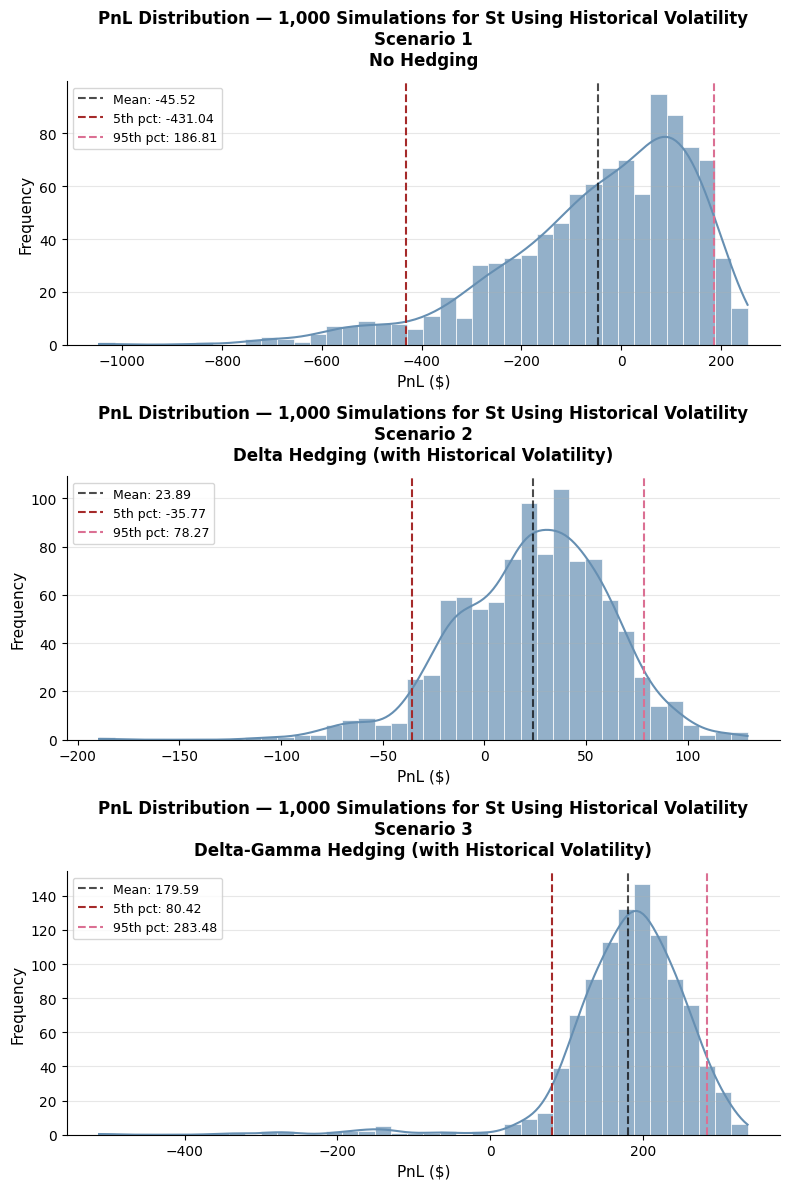

In [38]:
fig, axes = plt.subplots(3, 1, figsize=(8, 12))

scenarios = [
    (total_pnl_scenario1, 'Scenario 1\nNo Hedging', '#668fb2'),
    (total_pnl_scenario2, 'Scenario 2\nDelta Hedging (with Historical Volatility)', '#668fb2'),
    (total_pnl_scenario3, 'Scenario 3\nDelta-Gamma Hedging (with Historical Volatility)', '#668fb2')
]

for ax, (data, title, color) in zip(axes, scenarios):
    sns.histplot(data, bins=40, ax=ax, color=color, alpha=0.7, edgecolor='white', linewidth=0.5, kde=True)
    ax.axvline(data.mean(), color='black', linestyle='--', alpha=0.7, linewidth=1.5, label=f'Mean: {data.mean():,.2f}')
    ax.axvline(np.percentile(data, 5), color='brown', linestyle='--', linewidth=1.5, label=f'5th pct: {np.percentile(data, 5):,.2f}')
    ax.axvline(np.percentile(data, 95), color='palevioletred', linestyle='--', linewidth=1.5, label=f'95th pct: {np.percentile(data, 95):,.2f}')
    ax.set_title(f'PnL Distribution — 1,000 Simulations for St Using Historical Volatility\n{title}', fontsize=12, fontweight='bold', pad=12)
    ax.set_xlabel('PnL ($)', fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(axis='y', alpha=0.3)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

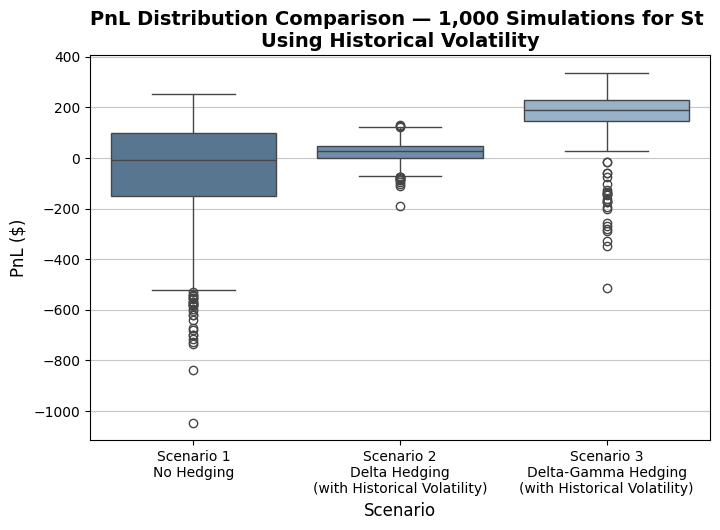

In [41]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=[total_pnl_scenario1, total_pnl_scenario2, total_pnl_scenario3], palette=['#507699', '#668fb2', '#90B2D1'])
plt.grid(axis='y', alpha=0.7)
plt.title('PnL Distribution Comparison — 1,000 Simulations for St \nUsing Historical Volatility', fontsize=14, fontweight='bold')
plt.xlabel('Scenario', fontsize=12)
plt.ylabel('PnL ($)', fontsize=12)
plt.xticks([0, 1, 2], ['Scenario 1\nNo Hedging', 'Scenario 2\nDelta Hedging\n(with Historical Volatility)', 'Scenario 3\nDelta-Gamma Hedging\n(with Historical Volatility)'])
plt.show()

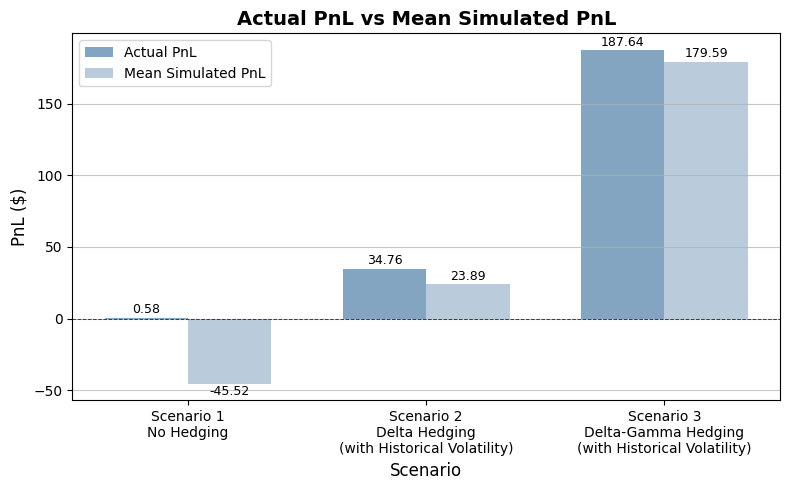

In [20]:
actual_pnls = [total_scenario_1, total_scenario_2, total_scenario_3]
mean_pnls = [total_pnl_scenario1.mean(), total_pnl_scenario2.mean(), total_pnl_scenario3.mean()]

labels = ['Scenario 1\nNo Hedging', 'Scenario 2\nDelta Hedging\n(with Historical Volatility)', 'Scenario 3\nDelta-Gamma Hedging\n(with Historical Volatility)']
x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(8, 5))
bars1 = plt.bar(x - width/2, actual_pnls, width=width, color=['#668fb2', '#668fb2', '#668fb2'], alpha=0.8, label='Actual PnL')
bars2 = plt.bar(x + width/2, mean_pnls, width=width, color=['#668fb2', '#668fb2', '#668fb2'], alpha=0.45, label='Mean Simulated PnL')

plt.bar_label(bars1, fmt='%.2f', padding=1, fontsize=9)
plt.bar_label(bars2, fmt='%.2f', padding=1, fontsize=9)

plt.title('Actual PnL vs Mean Simulated PnL', fontsize=14, fontweight='bold')
plt.xlabel('Scenario', fontsize=12)
plt.ylabel('PnL ($)', fontsize=12)
plt.grid(axis='y', alpha=0.7)
plt.axhline(0, color='black', linestyle='--', linewidth=0.7, alpha=0.7)
plt.xticks(x, labels)
plt.legend()
plt.tight_layout()
plt.show()

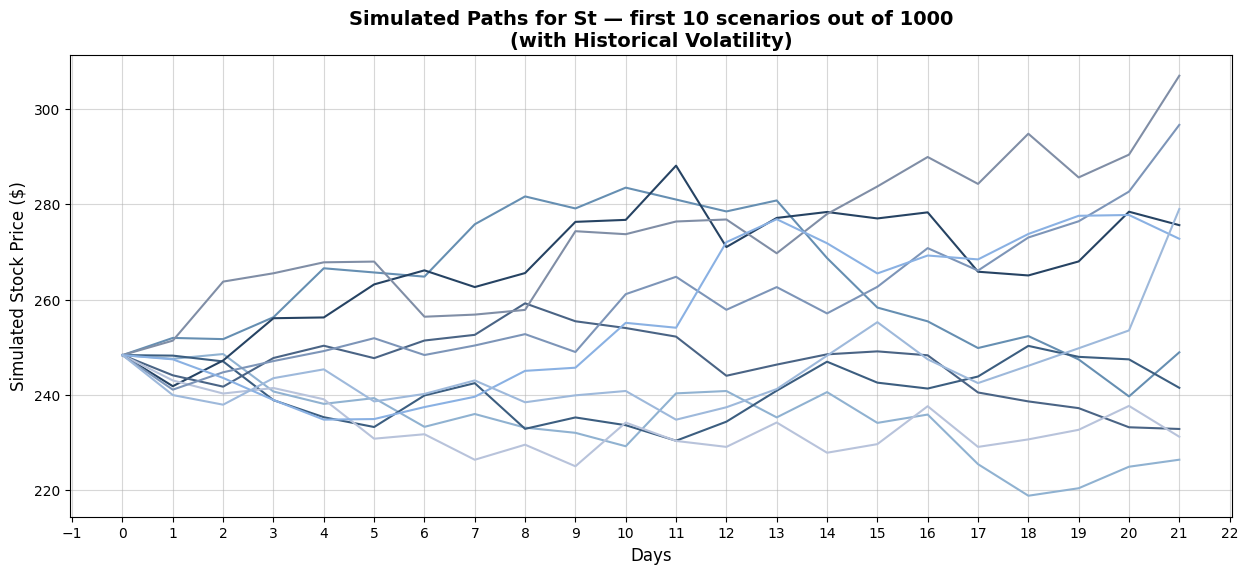

In [21]:
plt.figure(figsize=(15, 6))
colors_blue = ['#668fb2', '#90B2D1', '#3C5E80', '#264363', '#4A6485', '#808EA6', '#B8C3DB', '#7D95B8', '#8AB1E3', '#9EB9DB']

for i in range(10):
    plt.plot(paths_historical[i], color=colors_blue[i])

plt.gca().xaxis.set_major_locator(MultipleLocator(1)) 
plt.title('Simulated Paths for St — first 10 scenarios out of 1000\n(with Historical Volatility)', fontsize=14, fontweight='bold')
plt.xlabel('Days', fontsize=12)
plt.ylabel('Simulated Stock Price ($)', fontsize=12)
plt.grid(alpha=0.5)
plt.show()

<h1 style="color: steelblue; text-align: left; font-size: 35px; font-weight: 400; font-family: Georgia, 'Times New Roman', serif;">
    Implied Volatility Results for All Scenarios
</h1>

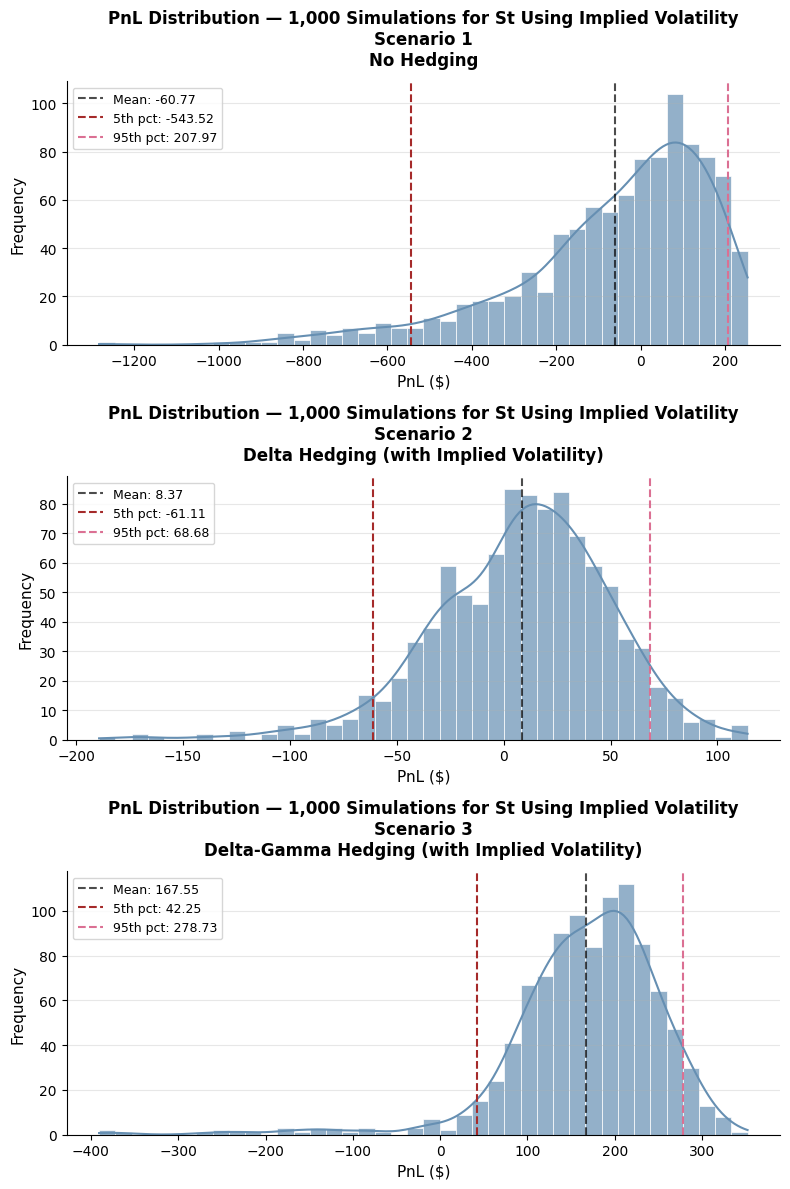

In [46]:
fig, axes = plt.subplots(3, 1, figsize=(8, 12))

scenarios = [
    (total_pnl_scenario1_iv, 'Scenario 1\nNo Hedging', '#668fb2'),
    (total_pnl_scenario2_iv, 'Scenario 2\nDelta Hedging (with Implied Volatility)', '#668fb2'),
    (total_pnl_scenario3_iv, 'Scenario 3\nDelta-Gamma Hedging (with Implied Volatility)', '#668fb2')
]

for ax, (data, title, color) in zip(axes, scenarios):
    sns.histplot(data, bins=40, ax=ax, color=color, alpha=0.7, edgecolor='white', linewidth=0.5, kde=True)
    ax.axvline(data.mean(), color='black', linestyle='--', alpha=0.7, linewidth=1.5, label=f'Mean: {data.mean():,.2f}')
    ax.axvline(np.percentile(data, 5), color='brown', linestyle='--', linewidth=1.5, label=f'5th pct: {np.percentile(data, 5):,.2f}')
    ax.axvline(np.percentile(data, 95), color='palevioletred', linestyle='--', linewidth=1.5, label=f'95th pct: {np.percentile(data, 95):,.2f}')
    ax.set_title(f'PnL Distribution — 1,000 Simulations for St Using Implied Volatility\n{title}', fontsize=12, fontweight='bold', pad=12)
    ax.set_xlabel('PnL ($)', fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(axis='y', alpha=0.3)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

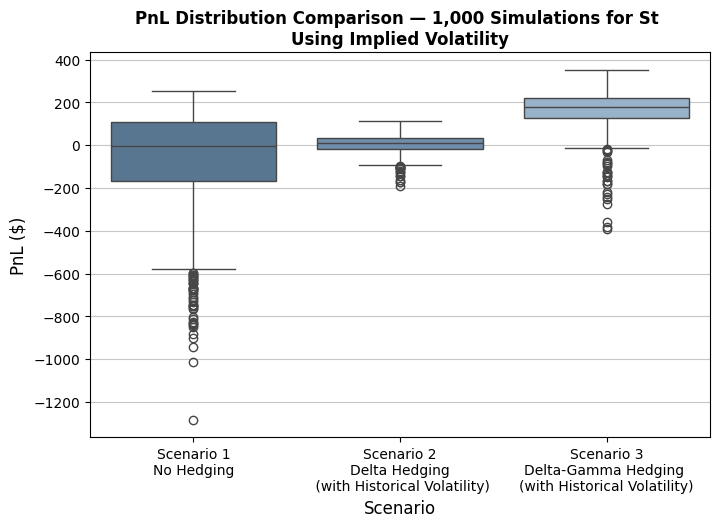

In [47]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=[total_pnl_scenario1_iv, total_pnl_scenario2_iv, total_pnl_scenario3_iv], palette=['#507699', '#668fb2', '#90B2D1'])
plt.grid(axis='y', alpha=0.7)
plt.title('PnL Distribution Comparison — 1,000 Simulations for St \nUsing Implied Volatility', fontsize=12, fontweight='bold')
plt.xlabel('Scenario', fontsize=12)
plt.ylabel('PnL ($)', fontsize=12)
plt.xticks([0, 1, 2], ['Scenario 1\nNo Hedging', 'Scenario 2\nDelta Hedging\n (with Historical Volatility)', 'Scenario 3\nDelta-Gamma Hedging \n(with Historical Volatility)'])
plt.show()

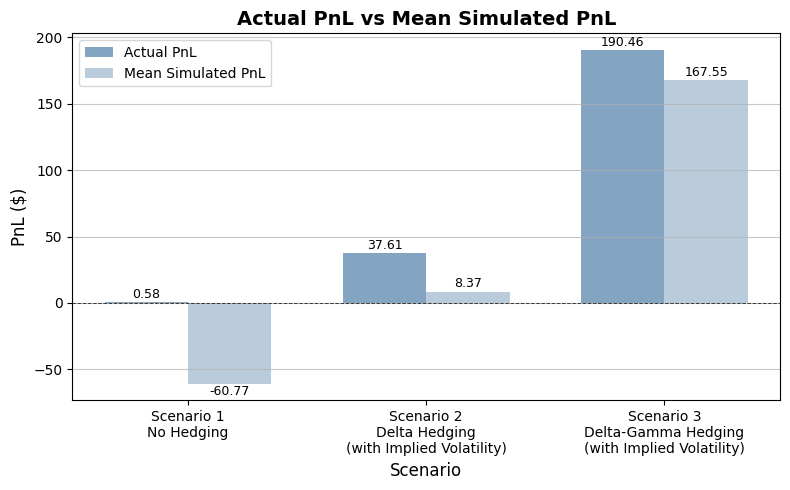

In [50]:
actual_pnls = [total_scenario_1, total_scenario_2_iv, total_scenario_3_iv]
mean_pnls = [total_pnl_scenario1_iv.mean(), total_pnl_scenario2_iv.mean(), total_pnl_scenario3_iv.mean()]

labels = ['Scenario 1\nNo Hedging', 'Scenario 2\nDelta Hedging\n(with Implied Volatility)', 'Scenario 3\nDelta-Gamma Hedging\n(with Implied Volatility)']
x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(8, 5))
bars1 = plt.bar(x - width/2, actual_pnls, width=width, color=['#668fb2', '#668fb2', '#668fb2'], alpha=0.8, label='Actual PnL')
bars2 = plt.bar(x + width/2, mean_pnls, width=width, color=['#668fb2', '#668fb2', '#668fb2'], alpha=0.45, label='Mean Simulated PnL')

plt.bar_label(bars1, fmt='%.2f', padding=1, fontsize=9)
plt.bar_label(bars2, fmt='%.2f', padding=1, fontsize=9)

plt.title('Actual PnL vs Mean Simulated PnL', fontsize=14, fontweight='bold')
plt.xlabel('Scenario', fontsize=12)
plt.ylabel('PnL ($)', fontsize=12)
plt.grid(axis='y', alpha=0.7)
plt.axhline(0, color='black', linestyle='--', linewidth=0.7, alpha=0.7)
plt.xticks(x, labels)
plt.legend()
plt.tight_layout()
plt.show()

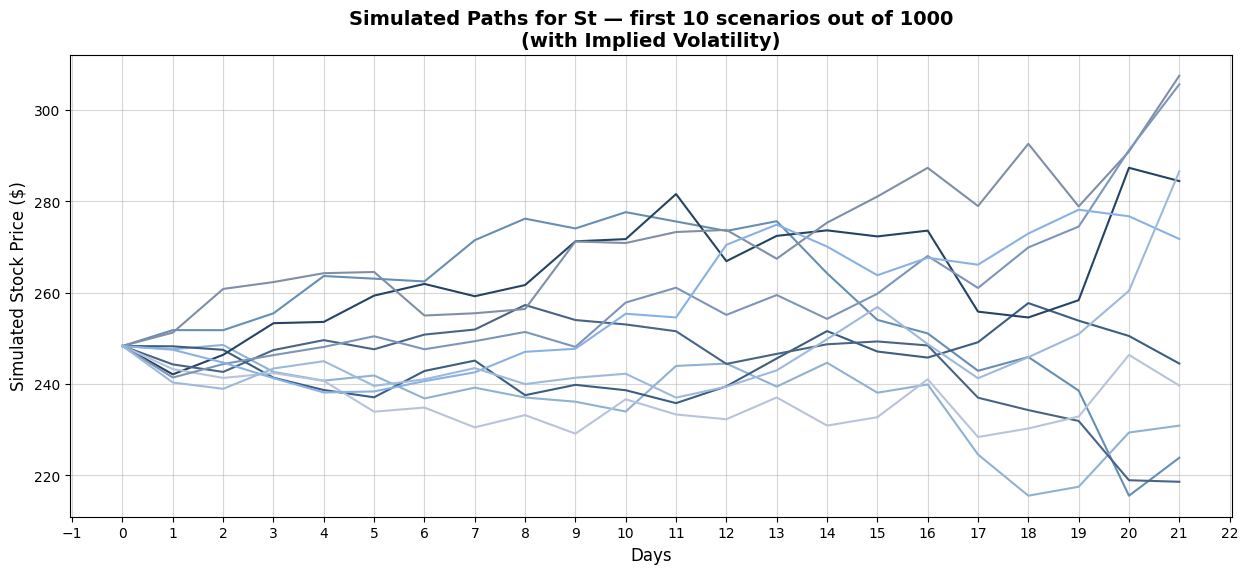

In [25]:
plt.figure(figsize=(15, 6))
colors_blue = ['#668fb2', '#90B2D1', '#3C5E80', '#264363', '#4A6485', '#808EA6', '#B8C3DB', '#7D95B8', '#8AB1E3', '#9EB9DB']

for i in range(10):
    plt.plot(paths_implied[i], color=colors_blue[i])

plt.gca().xaxis.set_major_locator(MultipleLocator(1)) 
plt.title('Simulated Paths for St — first 10 scenarios out of 1000\n(with Implied Volatility)', fontsize=14, fontweight='bold')
plt.xlabel('Days', fontsize=12)
plt.ylabel('Simulated Stock Price ($)', fontsize=12)
plt.grid(alpha=0.5)
plt.show()